In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/raw/diabetic_data.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
df.shape

(101766, 50)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [6]:
df['weight'].value_counts()

weight
?            98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64

In [7]:
df['weight'].value_counts()/101766 * 100

weight
?            96.858479
[75-100)      1.312816
[50-75)       0.881434
[100-125)     0.614154
[125-150)     0.142484
[25-50)       0.095317
[0-25)        0.047167
[150-175)     0.034393
[175-200)     0.010809
>200          0.002948
Name: count, dtype: float64

In [8]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [9]:
(df == '?').sum()/101766*100

encounter_id                 0.000000
patient_nbr                  0.000000
race                         2.233555
gender                       0.000000
age                          0.000000
weight                      96.858479
admission_type_id            0.000000
discharge_disposition_id     0.000000
admission_source_id          0.000000
time_in_hospital             0.000000
payer_code                  39.557416
medical_specialty           49.082208
num_lab_procedures           0.000000
num_procedures               0.000000
num_medications              0.000000
number_outpatient            0.000000
number_emergency             0.000000
number_inpatient             0.000000
diag_1                       0.020636
diag_2                       0.351787
diag_3                       1.398306
number_diagnoses             0.000000
max_glu_serum                0.000000
A1Cresult                    0.000000
metformin                    0.000000
repaglinide                  0.000000
nateglinide 

In [10]:
x = df.isnull() | (df == '?')
x.sum()/101766*100


encounter_id                 0.000000
patient_nbr                  0.000000
race                         2.233555
gender                       0.000000
age                          0.000000
weight                      96.858479
admission_type_id            0.000000
discharge_disposition_id     0.000000
admission_source_id          0.000000
time_in_hospital             0.000000
payer_code                  39.557416
medical_specialty           49.082208
num_lab_procedures           0.000000
num_procedures               0.000000
num_medications              0.000000
number_outpatient            0.000000
number_emergency             0.000000
number_inpatient             0.000000
diag_1                       0.020636
diag_2                       0.351787
diag_3                       1.398306
number_diagnoses             0.000000
max_glu_serum               94.746772
A1Cresult                   83.277322
metformin                    0.000000
repaglinide                  0.000000
nateglinide 

In [11]:
df['A1Cresult'].head(100)

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
     ... 
95    NaN
96    NaN
97    NaN
98     >8
99    NaN
Name: A1Cresult, Length: 100, dtype: str

In [12]:
df['a1c_missing'] = df['A1Cresult'].isnull()
df.groupby(['a1c_missing', 'readmitted']).size()


a1c_missing  readmitted
False        <30            1676
             >30            5800
             NO             9542
True         <30            9681
             >30           29745
             NO            45322
dtype: int64

In [13]:
a1c_available = 1676/(5800+1676+9542)*100
print(a1c_available)
a1c_Missing = 9681/(9681+29745+45322)*100
print(a1c_Missing)

9.848395816194618
11.423278425449567


In [14]:
df['readmitted'].value_counts()/101766 * 100

readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: count, dtype: float64

In [15]:
df['readmitted30_target'] = (df['readmitted'] == '<30').astype(int)
df['readmitted30_target'].value_counts()


readmitted30_target
0    90409
1    11357
Name: count, dtype: int64

In [16]:
# unique() → show me the unique values
# nunique() → number of unique values

df['patient_nbr'].nunique()

71518

In [17]:
df['patient_nbr'].value_counts()

patient_nbr
88785891     40
43140906     28
1660293      23
23199021     23
88227540     23
             ..
183087545     1
188574944     1
140199494     1
120975314     1
175429310     1
Name: count, Length: 71518, dtype: int64

In [18]:
df.select_dtypes(int).columns

Index(['encounter_id', 'patient_nbr', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient',
       'number_diagnoses', 'readmitted30_target'],
      dtype='str')

In [19]:
df['number_inpatient'].describe()

count    101766.000000
mean          0.635566
std           1.262863
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          21.000000
Name: number_inpatient, dtype: float64

<Axes: ylabel='number_inpatient'>

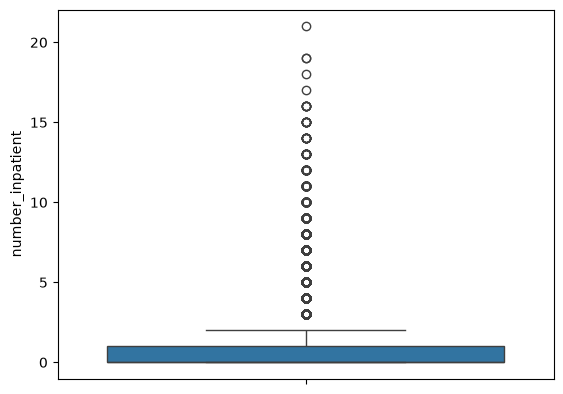

In [20]:
sns.boxplot(df['number_inpatient'])

In [21]:
df.groupby(['number_inpatient'])['readmitted30_target'].mean()*100


number_inpatient
0       8.437084
1      12.924543
2      17.433254
3      20.287306
4      23.612824
5      31.403941
6      34.583333
7      35.447761
8      44.370861
9      42.342342
10     42.622951
11     67.346939
12     50.000000
13     50.000000
14     40.000000
15    100.000000
16     33.333333
17    100.000000
18      0.000000
19     50.000000
21    100.000000
Name: readmitted30_target, dtype: float64

In [22]:
df.groupby(['number_inpatient']).size()

number_inpatient
0     67630
1     19521
2      7566
3      3411
4      1622
5       812
6       480
7       268
8       151
9       111
10       61
11       49
12       34
13       20
14       10
15        9
16        6
17        1
18        1
19        2
21        1
dtype: int64

<Axes: ylabel='number_emergency'>

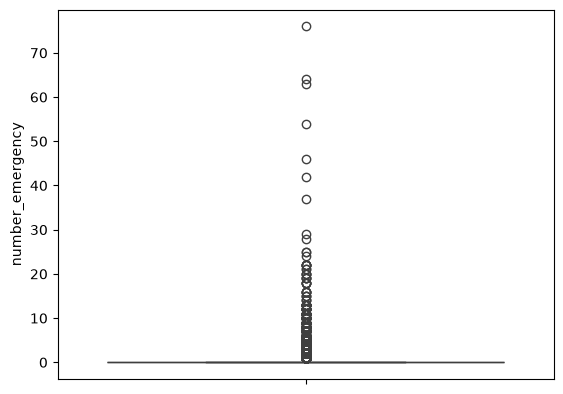

In [23]:
sns.boxplot(df['number_emergency'])

In [24]:
df.groupby(['number_emergency'])['readmitted30_target'].mean()*100


number_emergency
0      10.474315
1      14.354566
2      18.266405
3      20.275862
4      30.748663
5      24.479167
6      23.404255
7      26.027397
8      32.000000
9      36.363636
10     35.294118
11     21.739130
12     20.000000
13     33.333333
14      0.000000
15     33.333333
16     40.000000
18     20.000000
19     50.000000
20     50.000000
21     50.000000
22     50.000000
24      0.000000
25      0.000000
28    100.000000
29      0.000000
37      0.000000
42      0.000000
46      0.000000
54      0.000000
63      0.000000
64    100.000000
76      0.000000
Name: readmitted30_target, dtype: float64

In [25]:
df.groupby(['number_emergency']).size()

number_emergency
0     90383
1      7677
2      2042
3       725
4       374
5       192
6        94
7        73
8        50
9        33
10       34
11       23
12       10
13       12
14        3
15        3
16        5
18        5
19        4
20        4
21        2
22        6
24        1
25        2
28        1
29        1
37        1
42        1
46        1
54        1
63        1
64        1
76        1
dtype: int64

<Axes: ylabel='number_outpatient'>

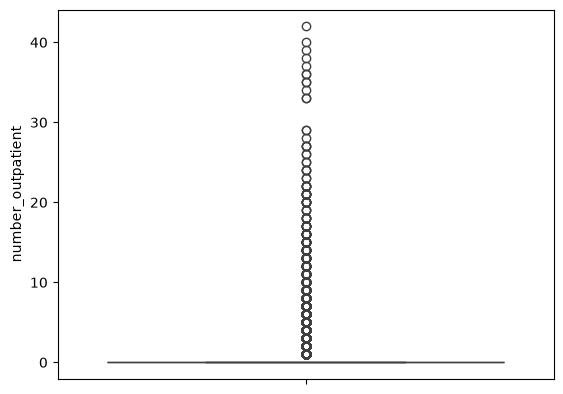

In [26]:
sns.boxplot(df['number_outpatient'])

In [27]:
df.groupby(df['number_outpatient'])['readmitted30_target'].mean()*100

number_outpatient
0      10.674256
1      13.923014
2      13.745131
3      12.291871
4      15.104641
5      11.819887
6      13.201320
7      15.483871
8       5.102041
9      15.662651
10      8.771930
11     14.285714
12     20.000000
13     19.354839
14     17.857143
15     10.000000
16      0.000000
17     12.500000
18      0.000000
19     33.333333
20      0.000000
21      0.000000
22     20.000000
23     50.000000
24      0.000000
25      0.000000
26      0.000000
27      0.000000
28      0.000000
29      0.000000
33      0.000000
34      0.000000
35      0.000000
36      0.000000
37      0.000000
38      0.000000
39      0.000000
40    100.000000
42      0.000000
Name: readmitted30_target, dtype: float64

In [28]:
df.groupby(['number_outpatient']).size()

number_outpatient
0     85027
1      8547
2      3594
3      2042
4      1099
5       533
6       303
7       155
8        98
9        83
10       57
11       42
12       30
13       31
14       28
15       20
16       15
17        8
18        5
19        3
20        7
21        7
22        5
23        2
24        3
25        2
26        2
27        3
28        1
29        2
33        2
34        1
35        2
36        2
37        1
38        1
39        1
40        1
42        1
dtype: int64

<Axes: ylabel='time_in_hospital'>

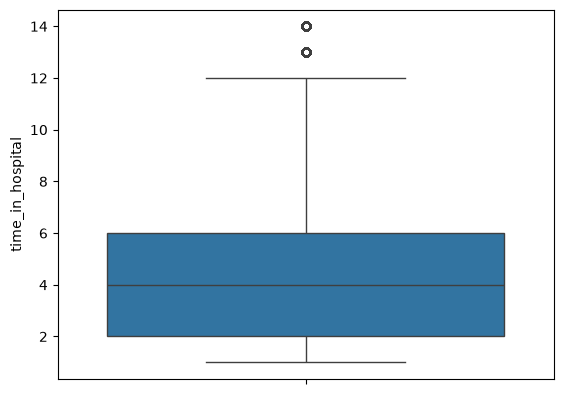

In [29]:
sns.boxplot(df['time_in_hospital'])

In [30]:
df.groupby(df['time_in_hospital'])['readmitted30_target'].mean()*100

time_in_hospital
1      8.178491
2      9.939619
3     10.666817
4     11.806952
5     12.030905
6     12.587876
7     12.834955
8     14.233660
9     13.724184
10    14.346712
11    10.512129
12    13.328729
13    12.314050
14    12.955854
Name: readmitted30_target, dtype: float64

In [31]:
df.groupby(['time_in_hospital']).size()

time_in_hospital
1     14208
2     17224
3     17756
4     13924
5      9966
6      7539
7      5859
8      4391
9      3002
10     2342
11     1855
12     1448
13     1210
14     1042
dtype: int64

<Axes: ylabel='num_medications'>

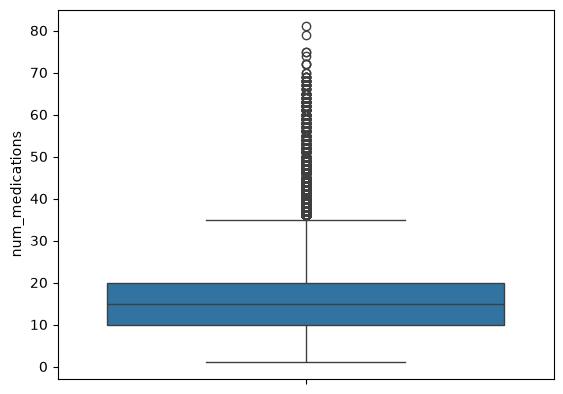

In [32]:
sns.boxplot(df['num_medications'])

In [33]:
result1 = df.groupby(df['num_medications'])['readmitted30_target'].mean()*100
result1.loc[10:30]

num_medications
10     9.970071
11    10.371009
12    10.776149
13    10.992442
14    10.758717
15    11.654006
16    11.491713
17    12.156942
18    12.182180
19    12.236390
20    13.112978
21    12.972136
22    13.423989
23    12.778236
24    13.750593
25    11.811441
26    12.810945
27    12.360335
28    11.922141
29    14.400000
30    11.660777
Name: readmitted30_target, dtype: float64

In [34]:
result2 = df.groupby(['num_medications']).size()
result2.loc[10:30]

num_medications
10    5346
11    5795
12    6004
13    6086
14    5707
15    5792
16    5430
17    4919
18    4523
19    4078
20    3691
21    3230
22    2868
23    2426
24    2109
25    1888
26    1608
27    1432
28    1233
29    1000
30     849
dtype: int64

<Axes: ylabel='number_diagnoses'>

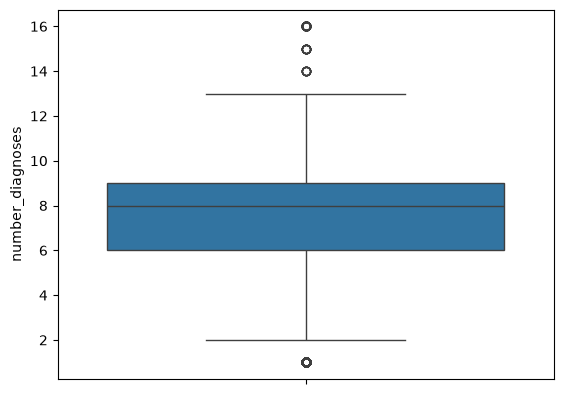

In [35]:
sns.boxplot(df['number_diagnoses'])

In [36]:
df.groupby(df['number_diagnoses'])['readmitted30_target'].mean()*100

number_diagnoses
1      5.936073
2      6.060606
3      7.372134
4      8.253567
5      9.154744
6     10.412361
7     10.766862
8     11.812359
9     12.380240
10    17.647059
11    27.272727
12    11.111111
13    18.750000
14    14.285714
15    20.000000
16     8.888889
Name: readmitted30_target, dtype: float64

In [37]:
df.groupby(df['number_diagnoses']).size()

number_diagnoses
1       219
2      1023
3      2835
4      5537
5     11393
6     10161
7     10393
8     10616
9     49474
10       17
11       11
12        9
13       16
14        7
15       10
16       45
dtype: int64

<Axes: ylabel='num_lab_procedures'>

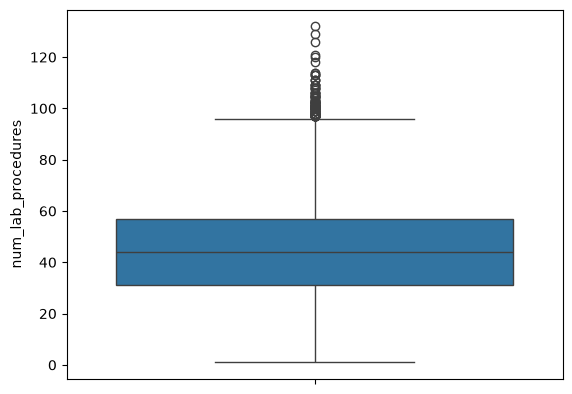

In [38]:
sns.boxplot(df['num_lab_procedures'])

In [39]:
df.groupby(df['num_lab_procedures'])['readmitted30_target'].mean()*100


num_lab_procedures
1        9.413965
2       11.444142
3        9.431138
4        6.349206
5        9.440559
          ...    
120      0.000000
121      0.000000
126      0.000000
129      0.000000
132    100.000000
Name: readmitted30_target, Length: 118, dtype: float64

In [40]:
df.groupby('readmitted30_target')['num_lab_procedures'].mean()

readmitted30_target
0    42.953644
1    44.226028
Name: num_lab_procedures, dtype: float64

In [41]:
df.groupby(df['num_lab_procedures']).size()

num_lab_procedures
1      3208
2      1101
3       668
4       378
5       286
       ... 
120       1
121       1
126       1
129       1
132       1
Length: 118, dtype: int64

In [42]:
df.groupby('readmitted30_target')['num_procedures'].mean()

readmitted30_target
0    1.347123
1    1.280884
Name: num_procedures, dtype: float64

In [43]:
df.groupby('readmitted30_target')['num_medications'].mean()

readmitted30_target
0    15.911137
1    16.903143
Name: num_medications, dtype: float64

<Axes: ylabel='num_procedures'>

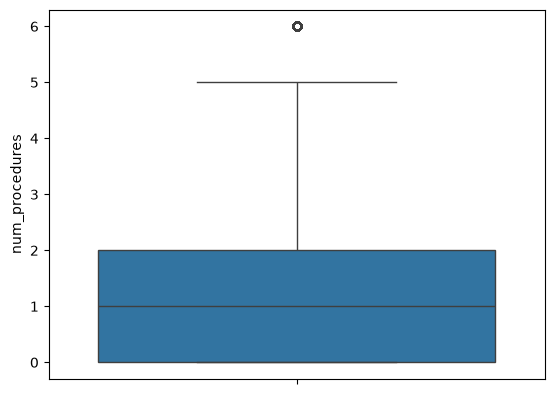

In [44]:
sns.boxplot(y=df['num_procedures'])

In [45]:
df['num_procedures'].value_counts().sort_index()

num_procedures
0    46652
1    20742
2    12717
3     9443
4     4180
5     3078
6     4954
Name: count, dtype: int64

<Axes: xlabel='readmitted30_target', ylabel='num_procedures'>

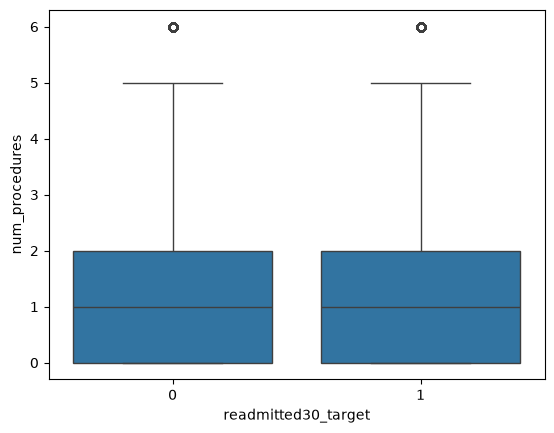

In [46]:
sns.boxplot(
    data=df,
    x='readmitted30_target',
    y='num_procedures'
)

In [47]:
df.groupby('readmitted30_target')['num_procedures'].mean()

readmitted30_target
0    1.347123
1    1.280884
Name: num_procedures, dtype: float64

In [48]:
df.groupby('readmitted30_target')['num_procedures'].agg(
    ['count', 'mean', 'median']
)

,count,mean,median
readmitted30_target,,,
0,90409,1.347123,1.0
1,11357,1.280884,1.0


In [49]:
df.groupby('num_procedures')['readmitted30_target'].mean() * 100

num_procedures
0    11.077767
1    12.207116
2    11.181883
3    10.685164
4    11.028708
5     9.421702
6     9.588212
Name: readmitted30_target, dtype: float64

In [50]:
df.select_dtypes(include='number').columns

Index(['encounter_id', 'patient_nbr', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient',
       'number_diagnoses', 'readmitted30_target'],
      dtype='str')

In [52]:
df.select_dtypes(exclude='number').columns

Index(['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty',
       'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted',
       'a1c_missing'],
      dtype='str')

In [62]:
result5 = df.nunique() 
result5[result5 > 50]

encounter_id          101766
patient_nbr            71518
medical_specialty         73
num_lab_procedures       118
num_medications           75
diag_1                   717
diag_2                   749
diag_3                   790
dtype: int64

In [63]:
df['age'].value_counts()

age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

In [65]:
df.groupby('readmitted30_target')['age'].value_counts()

readmitted30_target  age     
0                    [70-80)     22999
                     [60-70)     19981
                     [50-60)     15588
                     [80-90)     15119
                     [40-50)      8658
                     [30-40)      3351
                     [90-100)     2483
                     [20-30)      1421
                     [10-20)       651
                     [0-10)        158
1                    [70-80)      3069
                     [60-70)      2502
                     [80-90)      2078
                     [50-60)      1668
                     [40-50)      1027
                     [30-40)       424
                     [90-100)      310
                     [20-30)       236
                     [10-20)        40
                     [0-10)          3
Name: count, dtype: int64

In [67]:
df.groupby(df['age'])['readmitted30_target'].mean()*100

age
[0-10)       1.863354
[10-20)      5.788712
[20-30)     14.242607
[30-40)     11.231788
[40-50)     10.604027
[50-60)      9.666203
[60-70)     11.128408
[70-80)     11.773055
[80-90)     12.083503
[90-100)    11.099177
Name: readmitted30_target, dtype: float64

In [68]:
df['gender'].value_counts()

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

In [69]:
df['race'].value_counts()

race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

In [70]:
df.groupby('readmitted30_target')['gender'].value_counts()

readmitted30_target  gender         
0                    Female             48556
                     Male               41850
                     Unknown/Invalid        3
1                    Female              6152
                     Male                5205
Name: count, dtype: int64

In [72]:
df.groupby('readmitted30_target')['race'].value_counts()

readmitted30_target  race           
0                    Caucasian          67507
                     AfricanAmerican    17055
                     ?                   2085
                     Hispanic            1825
                     Other               1361
                     Asian                576
1                    Caucasian           8592
                     AfricanAmerican     2155
                     Hispanic             212
                     ?                    188
                     Other                145
                     Asian                 65
Name: count, dtype: int64

In [73]:
df.groupby(df['gender'])['readmitted30_target'].mean()*100

gender
Female             11.245156
Male               11.061524
Unknown/Invalid     0.000000
Name: readmitted30_target, dtype: float64

In [74]:
df.groupby(df['race'])['readmitted30_target'].mean()*100

race
?                   8.271007
AfricanAmerican    11.218116
Asian              10.140406
Caucasian          11.290556
Hispanic           10.407462
Other               9.628154
Name: readmitted30_target, dtype: float64

In [75]:
df['discharge_disposition_id'].value_counts()

discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
11     1642
5      1184
25      989
4       815
7       623
23      412
13      399
14      372
28      139
8       108
15       63
24       48
9        21
17       14
16       11
19        8
10        6
27        5
12        3
20        2
Name: count, dtype: int64

In [ ]:
df.groupby(df['discharge_disposition_id'])['readmitted30_target'].mean()*100

discharge_disposition_id
1      9.300395
2     16.071429
3     14.662462
4     12.760736
5     20.861486
6     12.695706
7     14.446228
8     13.888889
9     42.857143
10     0.000000
11     0.000000
12    66.666667
13     4.761905
14     6.451613
15    44.444444
16     0.000000
17     0.000000
18    12.435654
19     0.000000
20     0.000000
22    27.696939
23     7.281553
24    14.583333
25     9.302326
27     0.000000
28    36.690647
Name: readmitted30_target, dtype: float64

In [78]:
df['admission_type_id'].value_counts()

admission_type_id
1    53990
3    18869
2    18480
6     5291
5     4785
8      320
7       21
4       10
Name: count, dtype: int64

In [79]:
df.groupby(df['admission_type_id'])['readmitted30_target'].mean()*100

admission_type_id
1    11.522504
2    11.179654
3    10.392708
4    10.000000
5    10.344828
6    11.075411
7     0.000000
8     8.437500
Name: readmitted30_target, dtype: float64

In [80]:
df['A1Cresult'].value_counts()

A1Cresult
>8      8216
Norm    4990
>7      3812
Name: count, dtype: int64

In [81]:
df.groupby(df['A1Cresult'])['readmitted30_target'].mean()*100

A1Cresult
>7      10.047219
>8       9.870983
Norm     9.659319
Name: readmitted30_target, dtype: float64

In [82]:
df['max_glu_serum'].value_counts()

max_glu_serum
Norm    2597
>200    1485
>300    1264
Name: count, dtype: int64

In [83]:
df.groupby(df['max_glu_serum'])['readmitted30_target'].mean()*100

max_glu_serum
>200    12.457912
>300    14.319620
Norm    11.359261
Name: readmitted30_target, dtype: float64

In [84]:
df['diabetesMed'].value_counts()

diabetesMed
Yes    78363
No     23403
Name: count, dtype: int64

In [85]:
df.groupby(df['diabetesMed'])['readmitted30_target'].mean()*100

diabetesMed
No      9.597060
Yes    11.626661
Name: readmitted30_target, dtype: float64

In [86]:
df['change'].value_counts()

change
No    54755
Ch    47011
Name: count, dtype: int64

In [87]:
df.groupby(df['change'])['readmitted30_target'].mean()*100

change
Ch    11.822765
No    10.590814
Name: readmitted30_target, dtype: float64

In [88]:
df['insulin'].value_counts()

insulin
No        47383
Steady    30849
Down      12218
Up        11316
Name: count, dtype: int64

In [89]:
df.groupby(df['insulin'])['readmitted30_target'].mean()*100

insulin
Down      13.897528
No        10.037355
Steady    11.128400
Up        12.990456
Name: readmitted30_target, dtype: float64

In [90]:
df['metformin'].value_counts()

metformin
No        81778
Steady    18346
Up         1067
Down        575
Name: count, dtype: int64

In [91]:
df.groupby(df['metformin'])['readmitted30_target'].mean()*100

metformin
Down      12.000000
No        11.516545
Steady     9.713289
Up         8.247423
Name: readmitted30_target, dtype: float64

In [100]:
df['diag_1'].value_counts().head(10)

diag_1
428    6862
414    6581
786    4016
410    3614
486    3508
427    2766
491    2275
715    2151
682    2042
434    2028
Name: count, dtype: int64

In [93]:
df.groupby(df['diag_1'])['readmitted30_target'].mean()*100

diag_1
10      0.000000
11      0.000000
110     0.000000
112    19.178082
114     0.000000
         ...    
V63    12.500000
V66     0.000000
V67     0.000000
V70     0.000000
V71     0.000000
Name: readmitted30_target, Length: 717, dtype: float64

In [99]:
df['diag_2'].value_counts().head(10)

diag_2
276    6752
428    6662
250    6071
427    5036
401    3736
496    3305
599    3288
403    2823
414    2650
411    2566
Name: count, dtype: int64

In [94]:
df.groupby(df['diag_2'])['readmitted30_target'].mean()*100

diag_2
11      33.333333
110     25.000000
111      0.000000
112     13.930348
114    100.000000
          ...    
V69      0.000000
V70      0.000000
V72      0.000000
V85     13.017751
V86      0.000000
Name: readmitted30_target, Length: 749, dtype: float64

In [98]:
df['diag_3'].value_counts().head(10)

diag_3
250    11555
401     8289
276     5175
428     4577
427     3955
414     3664
496     2605
403     2357
585     1992
272     1969
Name: count, dtype: int64

In [95]:
df.groupby(df['diag_3'])['readmitted30_target'].mean()*100

diag_3
11      50.000000
110     10.000000
111    100.000000
112     10.679612
115      0.000000
          ...    
V66      5.555556
V70      0.000000
V72     12.500000
V85      9.375000
V86      0.000000
Name: readmitted30_target, Length: 790, dtype: float64